<a href="https://colab.research.google.com/github/BryanHinostroza/lab13-bh/blob/develop/MDD_GLAB13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 13: AJUSTE DE HIPERPARÁMETROS DE UN MODELO. ESTRATEGIAS DE COMPARACIÓN Y EVALUACIÓN DE DIFERENTES MODELOS**

## INTEGRANTES:
- GUTIERREZ GARCIA, Angela Belen
- HINOSTROZA MARTINEZ, Bryan Jesus

In [ ]:
!pip install ucimlrepo

## Tomando la información disponible en el repositorio UCI Machine Learning https://archive.ics.uci.edu/ml/datasets/Productivity+Prediction+of+Garment+Employees, pero eliminando previamente a la variable ‘date’ y definiendo a la variable ‘actual_productivity’ conbase a dos categorías (0 cuando ‘actual_productivity’ < 0.5 y 1 cuando ‘actual_productivity’ ≥ 0.5) siendo esta la variable de clasificación, haga lo siguiente:

## PREGUNTA A:
Realice el preprocesamiento de la información que incluya el análisis de datos faltantes y tratamiento de outliers a nivel univariado y multivariado. Además, convierta las variables categóricas a dummies y aplique un escalamiento a las variables numéricas.

In [ ]:

# 1. Importación de librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from ucimlrepo import fetch_ucirepo

In [ ]:
# 2. Carga y preparación inicial de los datos
data = fetch_ucirepo(id=597)  # Dataset: Productivity Prediction of Garment Employees
df = pd.concat([data.data.features, data.data.targets], axis=1)



In [ ]:
# 3. Eliminación de la variable 'date'
df.drop(columns=['date'], inplace=True)



In [ ]:
# 4. Binarización de 'actual_productivity'
df['actual_productivity'] = np.where(df['actual_productivity'] < 0.5, 0, 1)



In [ ]:
# 5. Análisis y tratamiento de valores faltantes
df.fillna(df.median(numeric_only=True), inplace=True)



In [ ]:
# 6. Detección y eliminación de outliers multivariados
numeric_cols = df.select_dtypes(include=np.number).columns
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df[numeric_cols])
df['outlier'] = outliers
df = df[df['outlier'] == 1].drop(columns='outlier')



In [ ]:
# 7. Codificación de variables categóricas a dummies
cat_cols = ['day', 'quarter', 'department', 'team']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)



In [ ]:
# 8. Escalamiento de variables numéricas
X = df.drop('actual_productivity', axis=1)
y = df['actual_productivity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## PREGUNTA B:
Separe los datos en entrenamiento (80%) y prueba (20%) y entrene los modelos k-NN, SVM,
regresión logística, árbol de clasificación, Random Forest y Naive Bayes definiendo distintos hiperparámetros para cada modelo.

<ipython-input-26-1647135046>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scores_df, x='Accuracy', y='Modelo', palette='viridis')


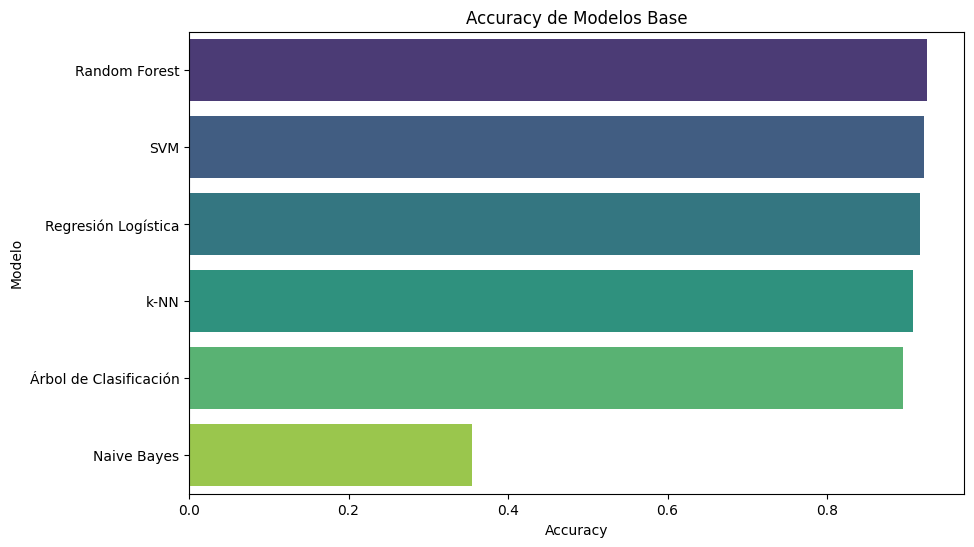

                   Modelo  Accuracy
4           Random Forest  0.925439
2                     SVM  0.921053
0     Regresión Logística  0.916667
1                    k-NN  0.907895
3  Árbol de Clasificación  0.894737
5             Naive Bayes  0.355263


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y)

# Inicialización de modelos
models = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=0),
    "k-NN": KNeighborsClassifier(),
    "SVM": SVC(random_state=0),
    "Árbol de Clasificación": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "Naive Bayes": GaussianNB()
}

# Entrenamiento y evaluación
baseline_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    baseline_scores[name] = acc

# Visualización de resultados
scores_df = pd.DataFrame(baseline_scores.items(), columns=['Modelo', 'Accuracy'])
scores_df = scores_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=scores_df, x='Accuracy', y='Modelo', palette='viridis')
plt.title("Accuracy de Modelos Base")
plt.show()

print(scores_df)


## PREGUNTA C:
Utilice hiperparámetros estándar, la búsqueda en cuadrícula y búsqueda aleatoria para poder
encontrar el modelo de clasificación con mejor desempeño. Luego, obtenga el mejor accuracy
junto con los hiperparámetros óptimos para dicho modelo.

In [ ]:
# C. Optimización de hiperparámetros

from sklearn.model_selection import RandomizedSearchCV

# Hiperparámetros para Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Resultados
best_rf = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

# Evaluación en conjunto de prueba
y_pred_final = best_rf.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_final)

print("--- Resultados de Optimización ---")
print("Mejor modelo: Random Forest")
print(f"Accuracy en conjunto de prueba: {final_accuracy:.4f}")
print("Mejores hiperparámetros encontrados:")
print(best_params)


--- Resultados de Optimización ---
Mejor modelo: Random Forest
Accuracy en conjunto de prueba: 0.9342
Mejores hiperparámetros encontrados:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
